In [1]:
import datetime
import json
import random
import time
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader, DistributedSampler

import datasets
import util.misc as utils
from datasets import build_dataset, get_coco_api_from_dataset
from engine import evaluate, train_one_epoch
from models import build_model

from models.detr import SetCriterion
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
import argparse

import math
from PIL import Image
import requests
import copy

In [2]:
def get_args_parser():
    parser = argparse.ArgumentParser('Set transformer detector', add_help=False)
    parser.add_argument('--lr', default=1e-4, type=float)
    parser.add_argument('--lr_backbone', default=1e-5, type=float)
    parser.add_argument('--batch_size', default=2, type=int)
    parser.add_argument('--weight_decay', default=1e-4, type=float)
    parser.add_argument('--epochs', default=300, type=int)
    parser.add_argument('--lr_drop', default=200, type=int)
    parser.add_argument('--clip_max_norm', default=0.1, type=float,
                        help='gradient clipping max norm')

    # Model parameters
    parser.add_argument('--frozen_weights', type=str, default=None,
                        help="Path to the pretrained model. If set, only the mask head will be trained")
    # * Backbone
    parser.add_argument('--backbone', default='resnet50', type=str,
                        help="Name of the convolutional backbone to use")
    parser.add_argument('--dilation', action='store_true',
                        help="If true, we replace stride with dilation in the last convolutional block (DC5)")
    parser.add_argument('--position_embedding', default='sine', type=str, choices=('sine', 'learned'),
                        help="Type of positional embedding to use on top of the image features")

    # * Transformer
    parser.add_argument('--enc_layers', default=6, type=int,
                        help="Number of encoding layers in the transformer")
    parser.add_argument('--dec_layers', default=6, type=int,
                        help="Number of decoding layers in the transformer")
    parser.add_argument('--dim_feedforward', default=2048, type=int,
                        help="Intermediate size of the feedforward layers in the transformer blocks")
    parser.add_argument('--hidden_dim', default=256, type=int,
                        help="Size of the embeddings (dimension of the transformer)")
    parser.add_argument('--dropout', default=0.1, type=float,
                        help="Dropout applied in the transformer")
    parser.add_argument('--nheads', default=8, type=int,
                        help="Number of attention heads inside the transformer's attentions")
    parser.add_argument('--num_queries', default=100, type=int,
                        help="Number of query slots")
    parser.add_argument('--pre_norm', action='store_true')

    # * Segmentation
    parser.add_argument('--masks', action='store_true',
                        help="Train segmentation head if the flag is provided")

    # Loss
    parser.add_argument('--no_aux_loss', dest='aux_loss', action='store_false',
                        help="Disables auxiliary decoding losses (loss at each layer)")
    # * Matcher
    parser.add_argument('--set_cost_class', default=1, type=float,
                        help="Class coefficient in the matching cost")
    parser.add_argument('--set_cost_bbox', default=5, type=float,
                        help="L1 box coefficient in the matching cost")
    parser.add_argument('--set_cost_giou', default=2, type=float,
                        help="giou box coefficient in the matching cost")
    # * Loss coefficients
    parser.add_argument('--mask_loss_coef', default=1, type=float)
    parser.add_argument('--dice_loss_coef', default=1, type=float)
    parser.add_argument('--bbox_loss_coef', default=5, type=float)
    parser.add_argument('--giou_loss_coef', default=2, type=float)
    parser.add_argument('--eos_coef', default=0.1, type=float,
                        help="Relative classification weight of the no-object class")

    # dataset parameters
    parser.add_argument('--dataset_file', default='coco')
    parser.add_argument('--coco_path', type=str)
    parser.add_argument('--coco_panoptic_path', type=str)
    parser.add_argument('--remove_difficult', action='store_true')

    parser.add_argument('--output_dir', default='',
                        help='path where to save, empty for no saving')
    parser.add_argument('--device', default='cuda',
                        help='device to use for training / testing')
    parser.add_argument('--seed', default=42, type=int)
    parser.add_argument('--resume', default='', help='resume from checkpoint')
    parser.add_argument('--start_epoch', default=0, type=int, metavar='N',
                        help='start epoch')
    parser.add_argument('--eval', action='store_true')
    parser.add_argument('--num_workers', default=2, type=int)

    # distributed training parameters
    parser.add_argument('--world_size', default=1, type=int,
                        help='number of distributed processes')
    parser.add_argument('--dist_url', default='env://', help='url used to set up distributed training')
    return parser

In [3]:
# COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

# standard PyTorch mean-std input image normalization
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size, device):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32).to(device)
    return b

def plot_results(pil_img, prob, boxes):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        cl = p.argmax()
        print(CLASSES[cl])
        text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

def fgsm_attack(image, epsilon, data_grad):
        # Collect the element-wise sign of the data gradient
        sign_data_grad = data_grad.sign()
        # Create the perturbed image by adjusting each pixel of the input image
        perturbed_image = image + epsilon*sign_data_grad
        # Adding clipping to maintain [-1.5,1.5] range
        perturbed_image = torch.clamp(perturbed_image, -1.5, 1.5)
        # Return the perturbed image
        return perturbed_image

class Adv_Dataset(torch.utils.data.Dataset):
    'Characterizes a dataset for PyTorch'
    def __init__(self, images, annotations):
        'Initialization'
        self.images = images
        self.annotations = annotations
    
    def __len__(self):
        'Denotes the total number of samples'
        return len(self.annotations)
    
    def __getitem__(self, index):
    
        # Load data and get label
        img = self.images[index]
        label = self.annotations[index]
    
        return img, label

In [4]:
parser = argparse.ArgumentParser('DETR training and evaluation script', parents=[get_args_parser()])
args = parser.parse_args(args=[])
args.batch_size = 1
args.no_aux_loss = True
args.eval = True
args.eval = True
args.resume = 'https://dl.fbaipublicfiles.com/detr/detr-r50-e632da11.pth'
# args.coco_path = '/home/anazeri/fiftyone/kitti_coco/'
args.coco_path = '/home/anazeri/Adv_ViT_OD/datasets/coco_dataset2017/'

# args.coco_path = 'coco/'

In [5]:
dataset_val = build_dataset(image_set='val', args=args)
sampler_val = torch.utils.data.SequentialSampler(dataset_val)
data_loader_val = DataLoader(dataset_val, args.batch_size, sampler=sampler_val, drop_last=False, collate_fn=utils.collate_fn, num_workers=args.num_workers)
base_ds = get_coco_api_from_dataset(dataset_val)

device = torch.device(args.device)
seed = args.seed + utils.get_rank()
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
model, criterion, postprocessors = build_model(args)
model.to(device)
model_without_ddp = model
n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('number of params:', n_parameters)

param_dicts = [
    {"params": [p for n, p in model_without_ddp.named_parameters() if "backbone" not in n and p.requires_grad]},
    {
        "params": [p for n, p in model_without_ddp.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": args.lr_backbone,
    },
]
optimizer = torch.optim.AdamW(param_dicts, lr=args.lr,
                              weight_decay=args.weight_decay)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, args.lr_drop)

output_dir = Path(args.output_dir)
if args.resume:
    if args.resume.startswith('https'):
        checkpoint = torch.hub.load_state_dict_from_url(
            args.resume, map_location='cpu', check_hash=True)
    else:
        checkpoint = torch.load(args.resume, map_location='cpu')
        
    model_without_ddp.load_state_dict(checkpoint['model'])
    
    if not args.eval and 'optimizer' in checkpoint and 'lr_scheduler' in checkpoint and 'epoch' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer'])
        lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
        args.start_epoch = checkpoint['epoch'] + 1

for param in model.parameters():
    param.requires_grad = False

model.zero_grad()
model.eval()
criterion.eval()

loading annotations into memory...
Done (t=0.78s)
creating index...
index created!


/home/anazeri/.conda/envs/Detr_env1/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/anazeri/.conda/envs/Detr_env1/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


number of params: 41302368


SetCriterion(
  (matcher): HungarianMatcher()
)

type of tensor_list::::::::::type of tensor_list:::::::::: <class 'tuple'> 
<class 'tuple'>
type of tensor_list:::::::::: <class 'tuple'>type of tensor_list:::::::::: 
<class 'tuple'>
type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list:::::::::: <class 'tuple'>


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


book
bed
book
book
book
book
book
book
book
book
book
book
book
book
book
book
chair
book
book
book
potted plant
book
book
book
bottle
book
book
book
book
book
book
potted plant
book
book
book
book
book
book
book
book
book
book
book
book
book
book


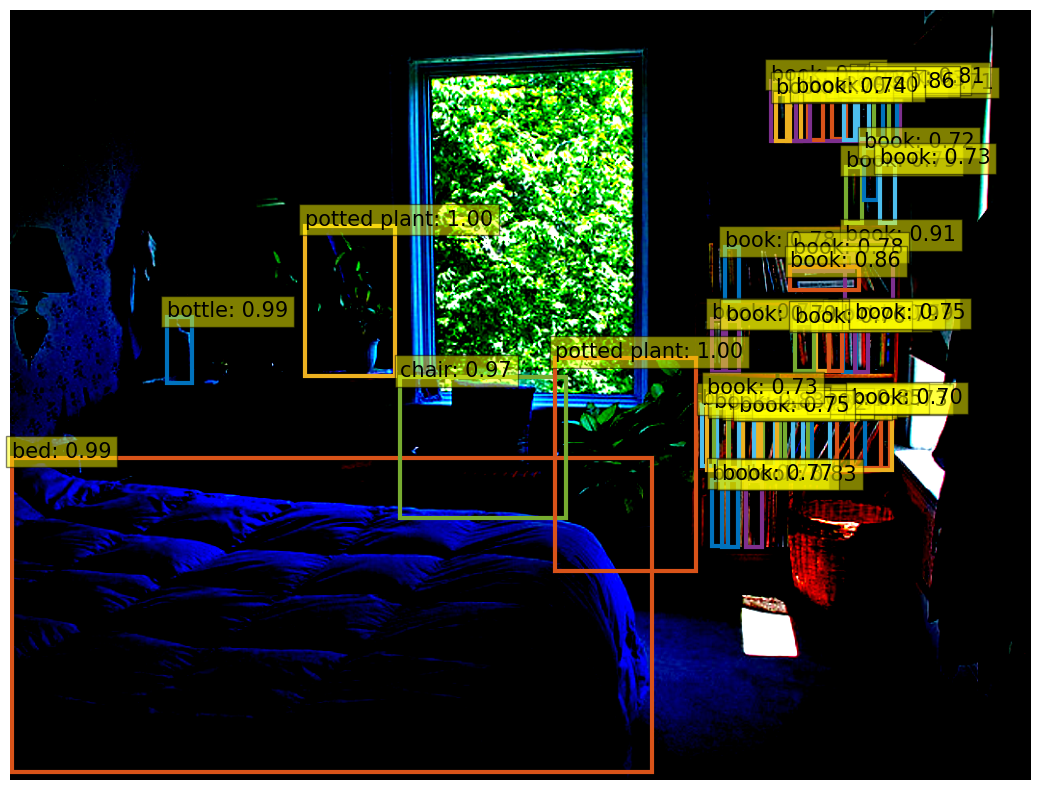

loss_ce: ............. tensor(-0.4913, device='cuda:0', grad_fn=<NegBackward0>)
img_gradddddddddddddddddddd:   tensor([[[[-1.3586e-05, -1.5489e-05, -2.2455e-05,  ...,  5.0407e-05,
            4.7556e-05,  5.3218e-05],
          [-1.4230e-05, -1.2365e-05, -1.5229e-05,  ...,  4.4154e-05,
            9.7202e-05,  1.0173e-04],
          [ 7.9354e-06,  2.8316e-06, -9.2427e-06,  ...,  9.9850e-05,
            9.3385e-05,  6.7346e-05],
          ...,
          [ 4.9715e-05,  1.8905e-05, -1.0492e-05,  ...,  1.9632e-05,
           -2.7446e-06, -3.7892e-06],
          [ 6.1124e-06,  3.1359e-05,  8.4140e-05,  ...,  3.8457e-06,
            5.2279e-06,  2.4126e-06],
          [-3.7419e-05, -2.9192e-05,  4.2223e-05,  ..., -6.7282e-07,
            1.0287e-05,  1.1115e-05]],

         [[-1.9271e-06,  3.0734e-07, -2.2567e-06,  ..., -4.3876e-05,
           -6.6857e-05, -5.9771e-05],
          [-1.8725e-06,  1.1237e-05,  1.6973e-05,  ..., -6.5155e-05,
           -3.7500e-05, -3.5595e-05],
          [ 2.67

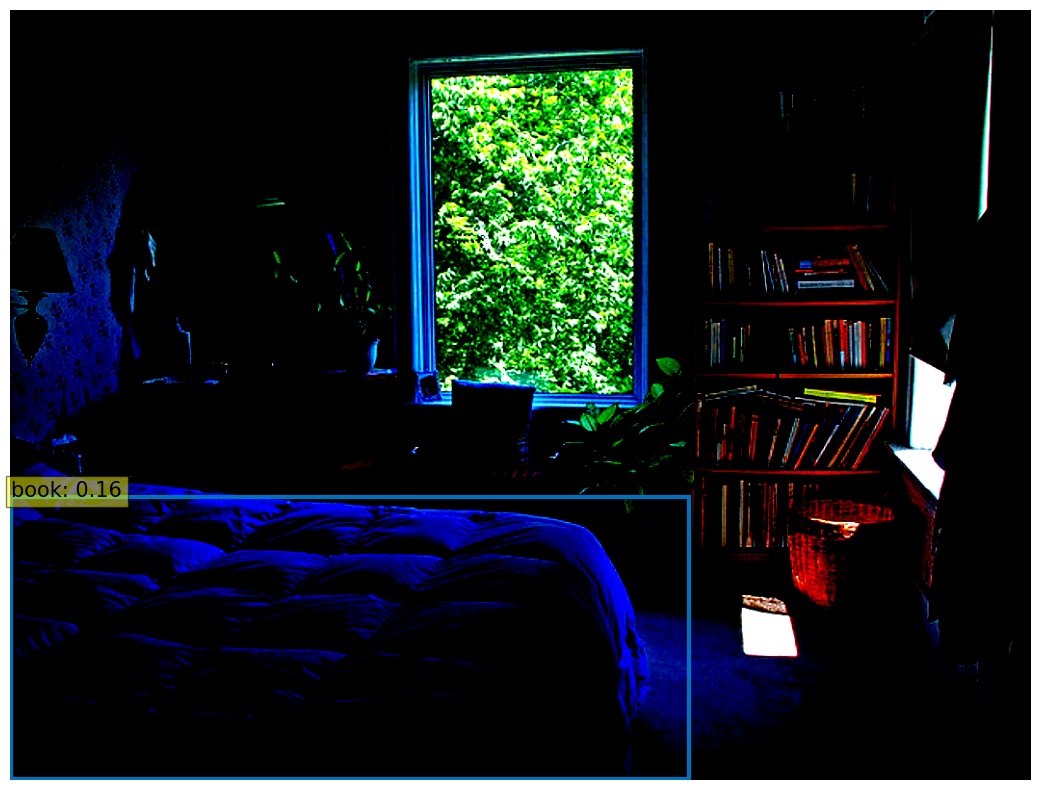

perturbed_img:     tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]], device='cuda:0',
       grad_fn=<ClampBackward1>)


In [86]:
epsilon = 0.0001
perturbed_img_list = []
for i, (img, annotation) in enumerate(data_loader_val):
    
    if i == 2:
        img_tensors = img.to(device)
        img_tensors.tensors.requires_grad = True
        outputs= model(img_tensors)
        im_size  = [img_tensors.tensors.size(dim = 3),img_tensors.tensors.size(dim = 2)]
        # keep only predictions with 0.7+ confidence
        probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
        keep = probas.max(-1).values > 0.7
        # convert boxes from [0; 1] to image scales
        bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], im_size, device)
        plot_results(img_tensors.tensors[0].detach().cpu().permute(1, 2, 0), probas[keep], bboxes_scaled)


        loss_dict = criterion(outputs, [annotation[0]])
        loss_ce= -loss_dict['loss_ce']
        # weight_dict = criterion.weight_dict
        print('loss_ce: .............', loss_ce)
        model.zero_grad()
        # Calculate gradients of model in backward pass
        loss_ce.backward()
        img_grad = img_tensors.tensors.grad
        #print(img_tensors.tensors.is_leaf)
        print("img_gradddddddddddddddddddd:  ", img_grad)
        # Call FGSM Attack
        perturbed_img = fgsm_attack(img_tensors.tensors, epsilon, img_grad)
        img_tensors.tensors = perturbed_img
        adv_outputs = model(img_tensors)

        # keep only predictions with 0.7+ confidence
        adv_probas = adv_outputs['pred_logits'].softmax(-1)[0, :, :-1]
        adv_keep = adv_probas.max(-1).values > 0.7
        # convert boxes from [0; 1] to image scales
        adv_bboxes_scaled = rescale_bboxes(adv_outputs['pred_boxes'][0, adv_keep], im_size, device)
        plot_results(perturbed_img[0].detach().cpu().permute(1, 2, 0), adv_probas[keep], adv_bboxes_scaled)
        print("perturbed_img:    ", perturbed_img)
        perturbed_img_list.append(perturbed_img)
    
        break

In [6]:
def normalize_0_1(img):
    tensor_image = img + (abs(img.max()) - abs(img.min()))/2
     # step 2: convert it to [0 ,1]
    tensor_image = tensor_image - tensor_image.min()
    tensor_image_0_1 = tensor_image / (tensor_image.max() - tensor_image.min())
    return tensor_image_0_1

In [25]:
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')
epsilon = 0.0
img_tensors_list = []
annotation_list = []
for i, (img, annotation) in enumerate(data_loader_val):

    img_tensors = img.to(device)
    img_tensors.tensors.requires_grad = True
    outputs= model(img_tensors)
    """
    im_size  = [img_tensors.tensors.size(dim = 3),img_tensors.tensors.size(dim = 2)]
    # keep only predictions with 0.7+ confidence
    probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > 0.7
    # convert boxes from [0; 1] to image scales
    bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], im_size, device)
    plot_results(img_tensors.tensors[0].detach().cpu().permute(1, 2, 0), probas[keep], bboxes_scaled)
    """
    
    loss_dict = criterion(outputs, [annotation[0]])
    loss_ce= -loss_dict['loss_ce']
    # weight_dict = criterion.weight_dict
    #print('loss_ce: .............', loss_ce)
    # Calculate gradients of model in backward pass
    loss_ce.backward()
    img_grad = img_tensors.tensors.grad
    #print(img_tensors.tensors.is_leaf)
    #print("img_gradddddddddddddddddddd:  ", img_grad)
    # Call FGSM Attack
    perturbed_img = fgsm_attack(img_tensors.tensors, epsilon, img_grad)
    #adv_tensors = copy.copy(img_tensors)
    img_tensors.tensors = perturbed_img

    
    
    """
    adv_outputs = model(adv_tensors)
    # keep only predictions with 0.7+ confidence
    adv_probas = adv_outputs['pred_logits'].softmax(-1)[0, :, :-1]
    adv_keep = adv_probas.max(-1).values > 0.7
    # convert boxes from [0; 1] to image scales
    adv_bboxes_scaled = rescale_bboxes(adv_outputs['pred_boxes'][0, adv_keep], im_size, device)
    plot_results(perturbed_img[0].detach().cpu().permute(1, 2, 0), adv_probas[keep], adv_bboxes_scaled)
    """

    # img_tensors_list.append(img_tensors.tensors[0].detach().cpu())
    img_tensors_list.append(normalize_0_1(img_tensors.tensors[0].detach().cpu()))
    annotation_list.append(annotation[0])

    
    print(i)
    # if i % 1000 == 0 and i != 0:
    #     print("%d Finished" % i)
    #     break
    if i == 10:
        break

adv_dataset_val = Adv_Dataset(img_tensors_list, annotation_list)
adv_sampler_val = torch.utils.data.SequentialSampler(adv_dataset_val)
adv_data_loader_val = DataLoader(adv_dataset_val, args.batch_size, sampler=adv_sampler_val, drop_last=False, collate_fn=utils.collate_fn, num_workers=args.num_workers)

"""
for i, (adv_img, annotation) in enumerate(adv_data_loader_val):
    adv_img_tensors = adv_img.to(device)
    adv_outputs= model(adv_img_tensors)
    im_size  = [adv_img_tensors.tensors.size(dim = 3),adv_img_tensors.tensors.size(dim = 2)]
    # keep only predictions with 0.7+ confidence
    probas = adv_outputs['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > 0.7
    # convert boxes from [0; 1] to image scales
    adv_bboxes_scaled = rescale_bboxes(adv_outputs['pred_boxes'][0, keep], im_size, device)
    plot_results(adv_img_tensors.tensors[0].detach().cpu().permute(1, 2, 0), probas[keep], adv_bboxes_scaled)
"""
test_stats, coco_evaluator = evaluate(model, criterion, postprocessors,
                                              adv_data_loader_val, base_ds, device, args.output_dir)

0
1
2
3
4
5
6
7
8
9
10
Test:  [ 0/11]  eta: 0:00:13  class_error: 45.00  loss: 17.6168 (17.6168)  loss_ce: 1.4959 (1.4959)  loss_bbox: 0.3839 (0.3839)  loss_giou: 0.9396 (0.9396)  loss_ce_0: 1.7620 (1.7620)  loss_bbox_0: 0.3571 (0.3571)  loss_giou_0: 0.9999 (0.9999)  loss_ce_1: 1.6472 (1.6472)  loss_bbox_1: 0.3327 (0.3327)  loss_giou_1: 1.0312 (1.0312)  loss_ce_2: 1.5316 (1.5316)  loss_bbox_2: 0.3829 (0.3829)  loss_giou_2: 0.9592 (0.9592)  loss_ce_3: 1.4909 (1.4909)  loss_bbox_3: 0.3876 (0.3876)  loss_giou_3: 0.9651 (0.9651)  loss_ce_4: 1.6782 (1.6782)  loss_bbox_4: 0.3324 (0.3324)  loss_giou_4: 0.9395 (0.9395)  loss_ce_unscaled: 1.4959 (1.4959)  class_error_unscaled: 45.0000 (45.0000)  loss_bbox_unscaled: 0.0768 (0.0768)  loss_giou_unscaled: 0.4698 (0.4698)  cardinality_error_unscaled: 2.0000 (2.0000)  loss_ce_0_unscaled: 1.7620 (1.7620)  loss_bbox_0_unscaled: 0.0714 (0.0714)  loss_giou_0_unscaled: 0.4999 (0.4999)  cardinality_error_0_unscaled: 16.0000 (16.0000)  loss_ce_1_unscaled: 1

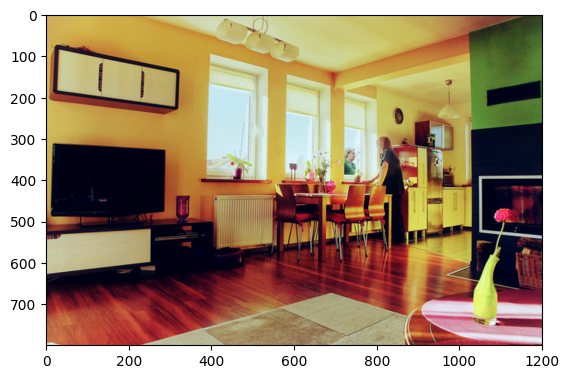

In [26]:
from torchvision.utils import save_image

img1= img_tensors_list[0]
img1.size()
# save_image(img1, "perturbed_img_tensors_list[2]_2.png")

plt.imshow(img1.permute(1, 2, 0))


vase
chair
chair
refrigerator
potted plant
chair
potted plant
vase
dining table
dining table
vase
bottle
chair
dining table
refrigerator
vase
chair
clock
person


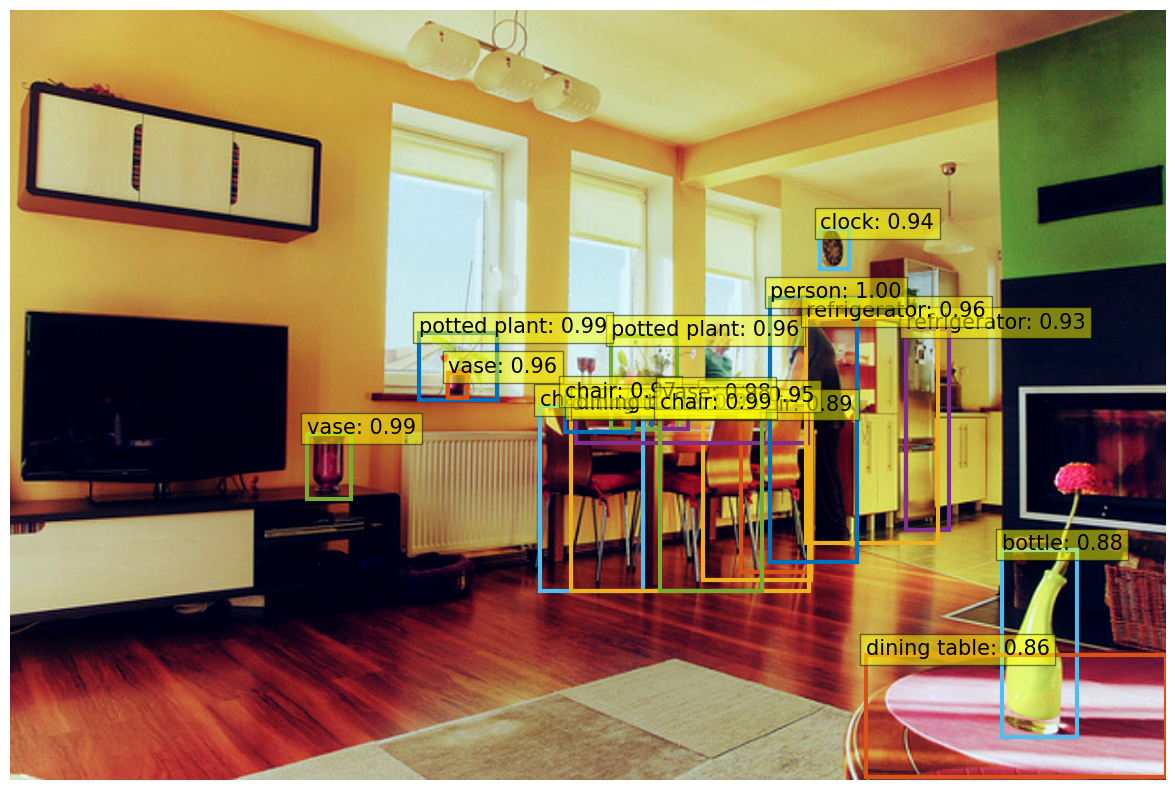

In [27]:
from util.misc import NestedTensor,nested_tensor_from_tensor_list

img2=img1.reshape([1,img1.size()[0],img1.size()[1], img1.size()[2]])
img_tensor= nested_tensor_from_tensor_list(img2)
img_tensors = img_tensor.to(device)

# img_tensors = img1.to(device)
outputs= model(img_tensors)
im_size  = [img_tensors.tensors.size(dim = 3),img_tensors.tensors.size(dim = 2)]
# keep only predictions with 0.7+ confidence
probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
keep = probas.max(-1).values > 0.7
# convert boxes from [0; 1] to image scales
bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], im_size, device)
plot_results(img_tensors.tensors[0].detach().cpu().permute(1, 2, 0), probas[keep], bboxes_scaled)

In [63]:
annotation[

{'boxes': tensor([[0.3596, 0.5656, 0.1168, 0.0783],
         [0.3040, 0.3120, 0.2180, 0.0400],
         [0.0824, 0.3215, 0.1648, 0.0355],
         [0.0782, 0.5811, 0.0836, 0.1627],
         [0.8919, 0.5843, 0.2161, 0.8049],
         [0.6796, 0.5837, 0.1020, 0.2071],
         [0.0195, 0.5843, 0.0390, 0.1888],
         [0.8496, 0.4447, 0.0464, 0.0439],
         [0.0517, 0.6020, 0.0352, 0.1207],
         [0.8500, 0.7298, 0.1610, 0.5324],
         [0.5506, 0.2687, 0.1901, 0.1345]]),
 'labels': tensor([16,  9,  9,  1,  1,  1,  1, 77, 27, 31,  9]),
 'image_id': tensor([1268]),
 'area': tensor([ 3635.4307,  6008.3779,  4213.8208,  8589.1816, 82453.7344, 13669.8027,
          5713.7559,  1385.3398,  2341.4448, 35156.4297,  6536.8120]),
 'iscrowd': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'orig_size': tensor([427, 640]),
 'size': tensor([ 800, 1199])}

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

bird
truck
car
car
car
car


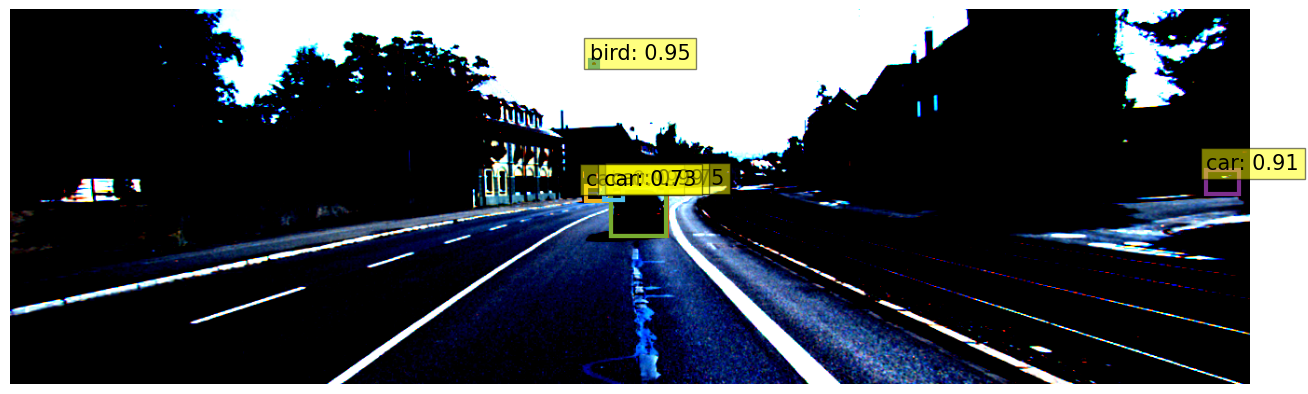

In [13]:
for i, (img, annotation) in enumerate(data_loader_val):
    
    if i == 9:

        img_tensors = img.to(device)
        img_tensors.tensors.requires_grad = True
        outputs= model(img_tensors)
        im_size  = [img_tensors.tensors.size(dim = 3),img_tensors.tensors.size(dim = 2)]
        # keep only predictions with 0.7+ confidence
        probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
        keep = probas.max(-1).values > 0.7
        # convert boxes from [0; 1] to image scales
        bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], im_size, device)
        plot_results(img_tensors.tensors[0].detach().cpu().permute(1, 2, 0), probas[keep], bboxes_scaled)
        
        
        break 

    
        

In [17]:
## test on Original clean dataset

img_clean_list =[]
annotation_clean_list = []
for i, (img, annotation) in enumerate(data_loader_val):
    
    img_clean_list.append(img.tensors[0].detach().cpu())
    annotation_clean_list.append(annotation[0])
    print(i)
    # if i % 1000 == 0 and i != 0:
    if i == 100:

        print("%d Finished" % i)
        break
        
        
        
_dataset_val = Adv_Dataset(img_clean_list, annotation_clean_list)
_sampler_val = torch.utils.data.SequentialSampler(_dataset_val)
_data_loader_val = DataLoader(_dataset_val, args.batch_size, sampler=_sampler_val, drop_last=False, collate_fn=utils.collate_fn, num_workers=args.num_workers)

test_stats, coco_evaluator = evaluate(model, criterion, postprocessors,
                                              _data_loader_val, base_ds, device, args.output_dir)

type of tensor_list:::::::::: <class 'tuple'>
type of tensor_list:::::::::: <class 'tuple'>
type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

0
1
2
3
4
5
6
7
type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

8
9
10
11
12
13
14
15
type of tensor_list::::::::::type of tensor_list::::::::::  <class 'tuple'><class 'tuple'>

type of tensor_list::::::::::type of tenso

In [2]:
i

NameError: name 'i' is not defined